# Medical DICOM to PNG Conversion Pipeline

This notebook processes CT scan data from the Kaggle Medical Deepfakes Lung Cancer dataset. It converts DICOM format medical images into normalized PNG slices for machine learning applications.

## Citation

This work uses the dataset from:

**Mirsky, Y., Mahler, T., Shelef, I., & Elovici, Y. (2019).** *CT-GAN: Malicious tampering of 3D medical imagery using deep learning.* In 28th USENIX Security Symposium (USENIX Security 19) (pp. 461-478).

```bibtex
@inproceedings{mirsky2019ct,
  title={CT-GAN: Malicious tampering of 3D medical imagery using deep learning},
  author={Mirsky, Yisroel and Mahler, Tom and Shelef, Ilan and Elovici, Yuval},
  booktitle={28th $\{$USENIX$\}$ Security Symposium ($\{$USENIX$\}$ Security 19)},
  pages={461--478},
  year={2019}
}
```

## Pipeline Overview:
1. Install dependencies and import libraries
2. Mount Google Drive and locate dataset
3. Load DICOM scans with spatial metadata
4. Normalize Hounsfield Units (HU) to [0,1] range
5. Export individual slices as PNG images organized by label

In [ ]:
# Install and import required dependencies
!pip install pydicom

# Core libraries
import numpy as np
import os
import pydicom # DICOM medical imaging format reader
import scipy.ndimage
from PIL import Image
from tqdm import tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.0 MB/s eta 0:00:00


## Dataset Access

The dataset can be accessed via Kaggle Hub or Google Drive. The code below shows both methods.

In [ ]:
# Alternative method: Download dataset using Kaggle Hub
# Uncomment if you want to download directly from Kaggle
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("ymirsky/medical-deepfakes-lung-cancer")

# print("Path to dataset files:", path)

In [ ]:
# Mount Google Drive to access folders
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## DICOM Loading Function

This function loads a complete CT scan from a directory of DICOM files and extracts important metadata:
- **Pixel data**: The actual image data from each slice
- **Spacing**: Physical distance between voxels (z, y, x)
- **Orientation**: Patient orientation in 3D space
- **Origin**: Physical location of the first slice

The function also sorts slices by their z-index to ensure correct anatomical ordering.

In [ ]:
import os
import numpy as np
import pydicom

def load_dicom(path2scan_dir):
    """
    Load a complete CT scan from a directory of DICOM files.

    Args:
        path2scan_dir: Path to directory containing DICOM slice files

    Returns:
        scan: 3D numpy array of pixel data (slices, height, width)
        spacing: Voxel spacing in (z, y, x) format
        orientation: Image orientation patient tag
        origin: Physical location of first slice in (z, y, x) format
        raw_slices: List of raw pydicom datasets sorted by z-position
    """

    dicom_folder = path2scan_dir
    dcms = os.listdir(dicom_folder)

    # Read the first slice to get dimensions and metadata
    first_slice_data = pydicom.dcmread(os.path.join(path2scan_dir, dcms[0]))
    first_slice = first_slice_data.pixel_array

    # Extract spatial metadata
    orientation = np.transpose(first_slice_data.ImageOrientationPatient)  # zyx format
    spacing_xy = np.array(first_slice_data.PixelSpacing, dtype=float)
    spacing_z = float(first_slice_data.SliceThickness)
    spacing = np.array([spacing_z, spacing_xy[1], spacing_xy[0]])  # z,y,x format

    # Initialize 3D array for the complete scan
    scan = np.zeros((len(dcms), first_slice.shape[0], first_slice.shape[1]))
    raw_slices = []
    indexes = []

    # Read all DICOM files and collect their z-positions
    for dcm in dcms:
        slice_data = pydicom.dcmread(os.path.join(dicom_folder, dcm))
        slice_data.filename = dcm
        raw_slices.append(slice_data)
        indexes.append(float(slice_data.ImagePositionPatient[2]))

    indexes = np.array(indexes, dtype=float)

    # Sort slices by z-index to ensure correct anatomical ordering
    raw_slices = [x for _, x in sorted(zip(indexes, raw_slices))]

    # Extract origin (first slice's physical location), convert x,y,z → z,y,x
    origin = np.array(raw_slices[0][0x00200032].value) if raw_slices[0][0x00200032].value is not None else np.zeros(3)
    origin = np.array([origin[2], origin[1], origin[0]])

    # Populate the 3D scan array with pixel data
    for i, slice in enumerate(raw_slices):
        scan[i, :, :] = slice.pixel_array

    return scan, spacing, orientation, origin, raw_slices

## Example: Loading a Single Scan

Let's load one scan from Experiment 1 to demonstrate the pipeline.

In [ ]:
# Let's load one of the scans from Experiment 1
scan_uuid = 8038
base_path = "/content/drive/MyDrive/KaggleMedicalDeepfakesLungCancer/CT_Scans/EXP1_blind/8038"

# Load the DICOM scan and its metadata
scan, spacing, orientation, origin, raw_slices = load_dicom(base_path)

# Print the 3D array shape: (num_slices, height, width)
print(scan.shape)

(249, 512, 512)


## Visualizing CT Slices

Display a sample of slices to verify the scan loaded correctly. The 'bone' colormap and HU window ([-1000, 2000]) are standard for viewing CT scans.

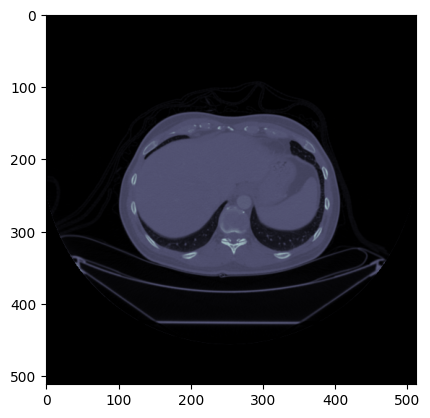

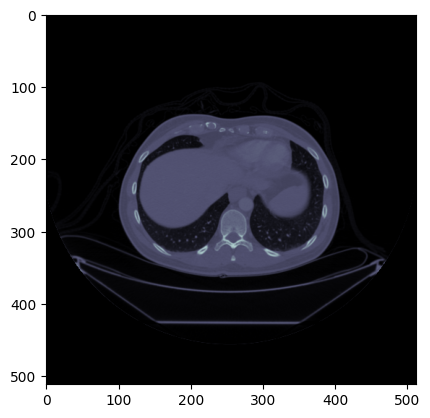

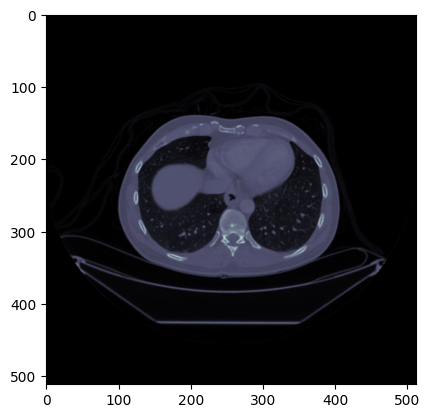

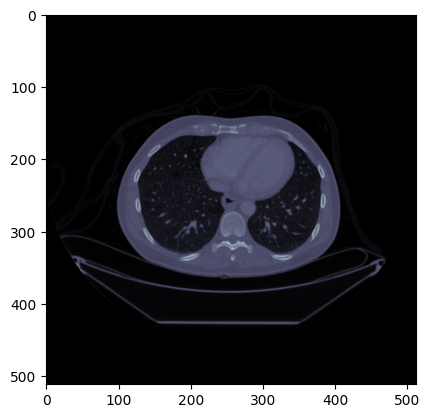

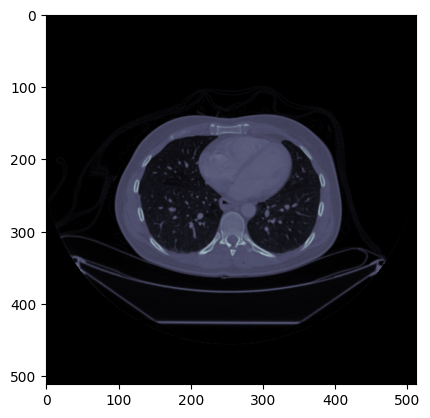

In [ ]:
# Visualize a few slices along the body axis
from matplotlib import pyplot as plt

# Show slices at 10-slice intervals from index 50 to 90
# vmin/vmax define the Hounsfield Unit window for optimal tissue contrast
for slice_indx in range(50,100,10):
    plt.imshow(scan[slice_indx,:,:],cmap='bone',vmin=-1000,vmax=2000)
    plt.show()

## Loading Labels

The labels file contains information about each scan including:
- **uuid**: Unique identifier for each scan
- **type**: Classification
- **coordinates**: Location of regions of interest

In [ ]:
# Import the labels for Experiment 1
import pandas as pd

# Load the CSV containing scan classifications and metadata
exp1_labels = pd.read_csv('/content/drive/MyDrive/KaggleMedicalDeepfakesLungCancer/labels_exp1.csv')

In [ ]:
# Find the label and regions of interest for our example scan
locations = exp1_labels.loc[exp1_labels['uuid']==scan_uuid]

# Note: 'FM' (False Malign) indicates this is a scan with synthetically injected cancer
print(locations)

   type  uuid  slice    x    y
87   FM  8038    123  169  207


## Hounsfield Unit Normalization

CT scans use Hounsfield Units (HU) to represent tissue density. This function normalizes HU values to the [0,1] range for consistent model input.

Values outside this range are clipped to focus on soft tissue and bone structures relevant for cancer detection.

In [ ]:
# Normalize the HU of the slices from [0,1]
def normalize_hu(scan, min_hu=-1000, max_hu=400):
    """
    Normalize CT scan Hounsfield Units to [0, 1] range.

    Args:
        scan: 3D numpy array of HU values
        min_hu: Minimum HU value
        max_hu: Maximum HU value

    Returns:
        Normalized scan with values in [0, 1]
    """

    # Clip values outside the HU window
    scan = np.clip(scan, min_hu, max_hu)

    # Linear normalization to [0, 1]
    scan = (scan - min_hu) / (max_hu - min_hu)

    return scan

## PNG Export Function

This function saves each 2D slice of a CT scan as a separate PNG image, organized into folders by label type. This format is more accessible for machine learning frameworks and visualization tools.

In [ ]:
# Save each slice of a CT scan as individual PNG files
def save_scan_slices(scan, output_base, uuid, label):
    """
    Export CT scan slices as PNG images organized by label.

    Args:
        scan: 3D numpy array with normalized values [0, 1]
        output_base: Base output directory
        uuid: Unique identifier for this scan
        label: Classification label
    """
    # Create label-specific subdirectories: TB, TM, FB, FM
    output_path = os.path.join(output_base, label)
    os.makedirs(output_path, exist_ok=True)

    # Save each slice as a PNG file with zero-padded numbering
    for i, slice2D in enumerate(scan):
        # Convert [0,1] float to [0,255] uint8 for PNG format
        img = Image.fromarray((slice2D * 255).astype(np.uint8))
        img.save(os.path.join(output_path, f"{uuid}_slice_{i:03d}.png"))

## Batch Processing: Convert All Scans

This is the main processing loop that:
1. Iterates through all scan directories in Experiment 1
2. Loads each scan's label from the CSV
3. Loads the DICOM files
4. Normalizes the Hounsfield Units
5. Exports all slices as PNG images organized by label

The output will be organized as: `{output_path}/{label}/{uuid}_slice_{number}.png`

In [ ]:
# Batch convert all DICOM scans to PNG images
# Define base paths
base_path = "/content/drive/MyDrive/KaggleMedicalDeepfakesLungCancer/CT_Scans/EXP1_blind"
output_path = "/content/drive/MyDrive/CT_PNG_512"

# Load labels CSV
labels_path = "/content/drive/MyDrive/KaggleMedicalDeepfakesLungCancer/labels_exp1.csv"
exp1_labels = pd.read_csv(labels_path)

# Get list of all scan directories (each directory name is a UUID)
scan_uuids = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

print(f"Found {len(scan_uuids)} scan folders")

# Process each scan with progress bar
for uuid in tqdm(scan_uuids):
    scan_dir = os.path.join(base_path, uuid)

    # Look up the label for this scan
    row = exp1_labels.loc[exp1_labels['uuid'] == int(uuid)]
    if row.empty:
        print(f"No label found for {uuid}, skipping.")
        continue

    label = row.iloc[0]['type']

    # Load the DICOM scan
    scan, spacing, orientation, origin, raw_slices = load_dicom(scan_dir)

    # Normalize Hounsfield Units to [0, 1]
    scan = normalize_hu(scan)

    # Export all slices as PNG files (preserving original 512x512 resolution)
    save_scan_slices(scan, output_path, uuid, label)

    print(f"Saved {scan.shape[0]} PNG slices for scan {uuid} ({label})")

Found 80 scan folders


  1%|▏         | 1/80 [00:43<57:18, 43.52s/it]

Saved 481 PNG slices for scan 1003 (FM)


  2%|▎         | 2/80 [01:17<49:31, 38.09s/it]

Saved 471 PNG slices for scan 1005 (FM)


...

Saved 126 PNG slices for scan 8971 (FM)


 99%|█████████▉| 79/80 [20:20<00:13, 13.30s/it]

Saved 246 PNG slices for scan 8972 (FM)


100%|██████████| 80/80 [21:07<00:00, 15.84s/it]

Saved 557 PNG slices for scan 9228 (FB)
